# Deep Convolutional Neural Networks on CIFAR-10

End-to-end Convolutional Neural Network (CNN) architecture design and training using TensorFlow/Keras, achieving multi-class object recognition with confusion matrix evaluation.


In [2]:
import os
import tensorflow as tf
import platform

print(f"TensorFlow Version: {tf.__version__}")
print(f"Python Version: {platform.python_version()}")
print(f"Operating System: {platform.system()}")

# If there are multiple GPUs and we only want to use one/some, set the number in the visible device list.
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

# This sets the GPU to allocate memory only as needed
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) != 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"Selected GPU: {physical_devices[0].name}")
    print(f"Memory growth enabled for GPU")
else:
    print("No GPU found. Using CPU instead.")

TensorFlow Version: 2.10.0
Python Version: 3.9.23
Operating System: Windows
Selected GPU: /physical_device:GPU:0
Memory growth enabled for GPU


### **1. Loading the dataset**
This assignment will focus on the CIFAR10 dataset. This is a collection of small images in 10 classes such as cars, cats, birds, etc. You can find more information here: https://www.cs.toronto.edu/~kriz/cifar.html. We start by loading and examining the data.

In [3]:
import numpy as np
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Shape of training data:")
print(X_train.shape) # 50 000 images, each 32x32 pixels with 3 color channels (RGB)
print(y_train.shape) # 50 000 labels, each a number from 0 to 9 representing the class of the image
print("Shape of test data:")
print(X_test.shape)
print(y_test.shape)

# The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, 
# with 6000 images per class. There are 50000 training images and 10000 test images.

Shape of training data:
(50000, 32, 32, 3)
(50000, 1)
Shape of test data:
(10000, 32, 32, 3)
(10000, 1)


#### **<span style="color:red">Question 1:</span>**
The shape of X_train and X_test has 4 values. What do each of these represent?

#### **<span style="color:green">Answer:</span>**

1. The number of images, 50 000 and 10 000
2. and 3. The number of pixels, 32x32
3. The RGB channels, 1 for each value

##### **Plotting some images**
This plots a random selection of images from each class. Rerun the cell to see a different selection.

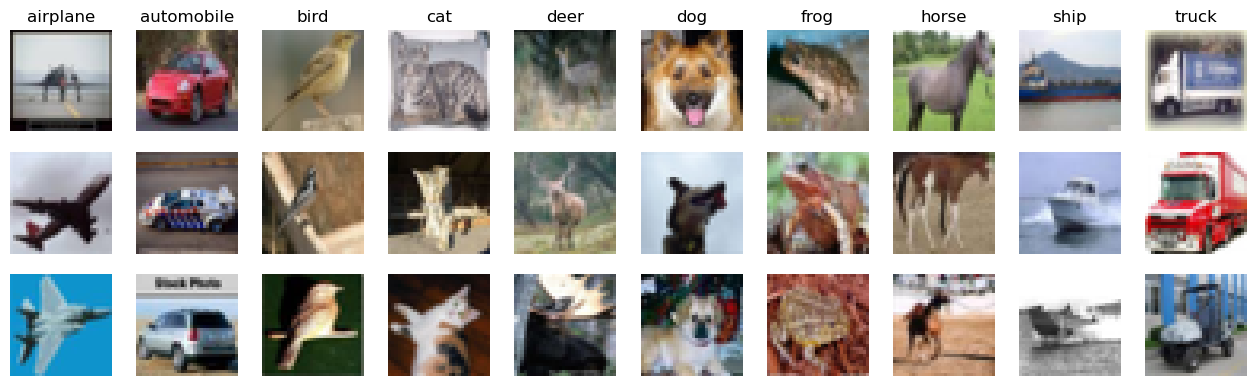

In [4]:
from Custom import PlotRandomFromEachClass

cifar_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
PlotRandomFromEachClass(X_train, y_train, 3, labels=cifar_labels)

##### **Preparing the dataset**
Just like the MNIST dataset we normalize the images to [0,1] and transform the class indices to one-hot encoded vectors.

In [5]:
from tensorflow.keras.utils import to_categorical

# Transform label indices to one-hot encoded vectors
y_train_c = to_categorical(y_train, num_classes=10)
y_test_c  = to_categorical(y_test , num_classes=10)

# Print some labels
print("Label index --> one-hot encoding")
for i in range(5):
    print(str(y_train[i]) + " --> " + str(y_train_c[i]))

# Normalization of pixel values (to [0-1] range)
X_train = X_train.astype('float32') / 255
X_test  = X_test.astype('float32')  / 255

Label index --> one-hot encoding
[6] --> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
[9] --> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[9] --> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[4] --> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[1] --> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


##### **Training and evaluating the model**
Below, we define a function that performs model training and evaluation. The first input parameter is another function that you will write, that creates and returns the model object in each task.

In order to show the differences between models in the first parts of the assignment, we will restrict the training to the following command using 15 epochs, batch size 32, and 20% validation data. From section 5 and forward you can change this as you please to increase the accuracy, but for now stick with this command.

We use ```model.evaluate``` to get the loss and metric scores on the test data. To plot the results we give you a custom function that does the work for you.

In [6]:
from Custom import PlotModelEval

def TrainModelAndPlotResults(get_model_func, epochs=15, batch_size=32):
    # Get model using function handle parameter
    model = get_model_func()

    # Build the model using Stochastic Gradient Descent with Nesterov momentum. We use accuracy as the metric.
    sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary(100)

    # Train the model and store the training history
    history = model.fit(X_train,y_train_c, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Evaluate on the test set and store the score
    score = model.evaluate(X_test, y_test_c, batch_size=128, verbose=0)

    # Print the result metrics
    print("")
    print('_' * 100)
    for i in range(len(score)):
        print("Test " + model.metrics_names[i] + " = %.3f" % score[i])
    print("")

    # Plot the training history and results
    PlotModelEval(model, history, X_test, y_test, cifar_labels)

### **2. Fully connected classifier**
We will start by creating a fully connected classifier using the ```Dense``` layer. We give you the first layer that flattens the image features to a single vector. Add the remaining layers to the network.

Consider what the size of the output must be and what activation function you should use in the output layer.

Model: "model_4"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 input_5 (InputLayer)                        [(None, 32, 32, 3)]                     0              
                                                                                                    
 flatten_4 (Flatten)                         (None, 3072)                            0              
                                                                                                    
 dense_8 (Dense)                             (None, 512)                             1573376        
                                                                                                    
 dense_9 (Dense)                             (None, 10)                              5130           
                                                                          

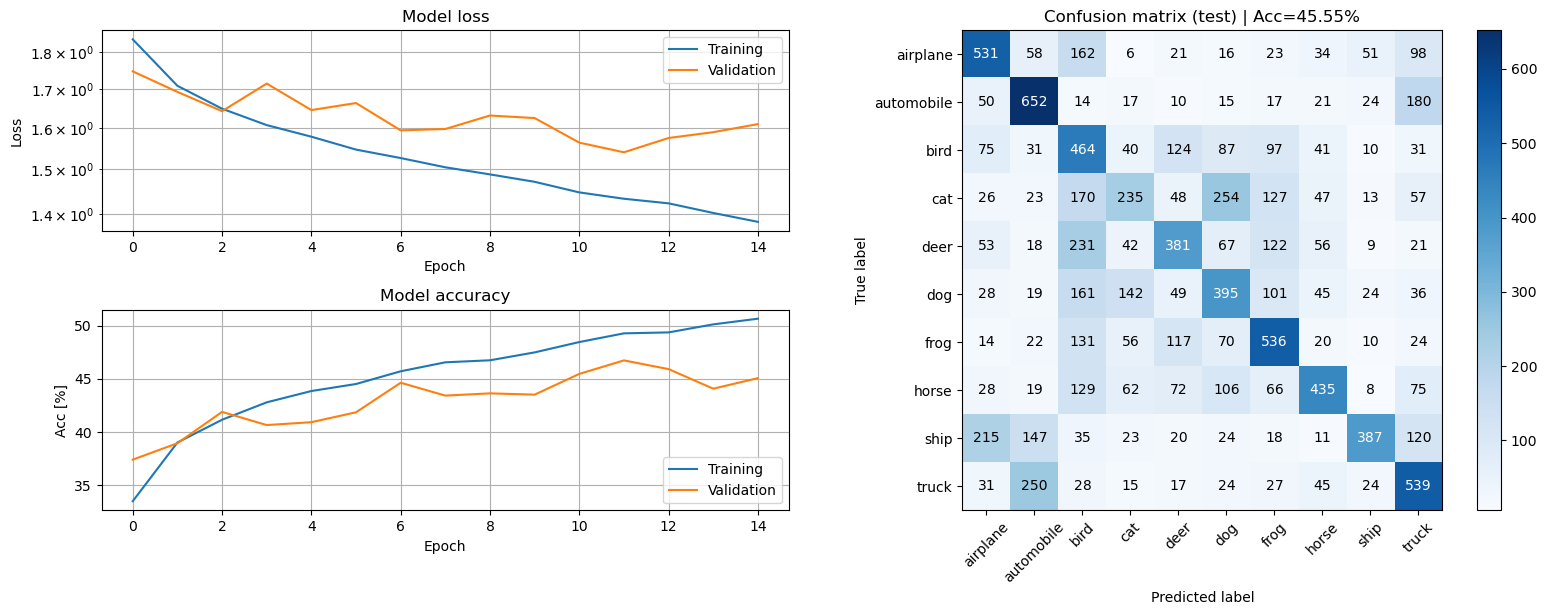

In [11]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization, Activation

def CreateFullyConnectedModel(): 

    x_in = Input(shape=X_train.shape[1:])
    x = Flatten()(x_in) # Flatten the 32x32x3 input into a 3072-dimensional vector
    # So Input is 3072 feature nodes
    # 3072 inputs -> 512 neurons 
          
    x = Dense(512, activation='relu')(x)
    
    # The output layer has 10 neurons. Classification with 10 numbers (classes)
    x = Dense(10, activation='softmax')(x) 
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the fully connected model
TrainModelAndPlotResults(CreateFullyConnectedModel)

# All this data is positive --> tanh performs worse

#### **<span style="color:red">Question 2:</span>**
Train a model that achieves above 45% accuracy on the test data. Provide a (short) motivation of your model architecture and briefly discuss the results.

#### **<span style="color:green">Answer:</span>**
Yesterday no combination of layers/sizes seemed to get the model over 34% (8000,4000,2000,1000,512,256) and all other combinations where tried but today 512 worked without issues.
* The model got 0 of some image classes in the confusion matrix and the loss function was still decreasing stedaliy.
* ReLU for faster training (max(0,x)) fixes vanishing gradient problem and low computational cost


**I USED:**  
Input $\rightarrow$ Flatten $\rightarrow$ Dense(256) $\rightarrow$ ReLU $\rightarrow$ Output


#### **<span style="color:red">Question 3:</span>**
Compare this model to the one you used for the MNIST dataset in the first assignment, in terms of size and test accuracy. Why do you think this dataset is much harder to classify than the MNIST handwritten digits?

#### **<span style="color:green">Answer:</span>**

The CIFAR-10 model is significantly larger in terms of parameters.  
MNIST Input: $28 \times 28 \times 1 = 784$ input features.  
CIFAR-10 Input: $32 \times 32 \times 3 = 3,072$ input features.

3D Objects vs. 2D Shapes: MNIST digits are flat, 2D geometric shapes. CIFAR images are 3D objects (animals, vehicles) projected onto a 2D image. The model must learn invariance to rotation, perspective, and lighting.

Background Noise: MNIST digits are on a clean, solid black background. CIFAR images have complex, noisy backgrounds (grass, sky, streets, other objects) that the model must learn to ignore.

Color Information: CIFAR images have 3 color channels (RGB). The model must learn that a "red car" and a "blue car" are the same class, adding a layer of complexity that grayscale MNIST lacks.

### **3. CNN classifier**
We will now move on to a network architecture that is more suited for this problem, the convolutional neural network. The new layers you will use are ```Conv2D``` and ```MaxPooling2D```, which you can find the documentation of here https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D and here https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D.

Conv2D = Convolutional Layer
* Uses a Kernel to extract features in the images such as edges. The result is a new set of filtered images, called **feature maps**, that highlight where those specific visual features were found.  

MaxPool2D = Max Pooling Layer
* MaxPool2D acts as a "summary tool" that shrinks the size of your feature maps to make the model more efficient and focused on the most important details. It slides a small window (usually $2 \times 2$) over the image and keeps only the largest (maximum) value from that window

##### **Creating the CNN model**

A common way to build convolutional neural networks is to create blocks of layers of the form **[convolution - activation - pooling]**, and then stack several of these block to create the full convolution stack. This is often followed by a fully connected network to create the output classes. Use this recipe to build a CNN that acheives at least 62% accuracy on the test data.

*Side note. Although this is a common way to build CNNs, it is be no means the only or even best way. It is a good starting point, but later in part 5 you might want to explore other architectures to acheive even better performance.*

**Padding:** The Problem: If the filter tries to center itself on the very top-left pixel of your image, part of the filter "hangs off" the edge. There are no numbers there to multiply with! Normally, the filter would just skip these edge pixels, causing your output image to shrink (from $32 \times 32$ down to $30 \times 30$).

**MaxPooling2D((2, 2)) (The Downsampler)**

This layer job is to reduce the size of the image to make the model faster and less prone to memorizing exact locations.  
* The Mechanism: It divides upp the $32 \times 32$ image grid into non-overlapping $2 \times 2$ squares and then the model looks at the 4 numbers inside each $2 \times 2$ square and picks only the largest one. (Max) 

* The Intuition: The "largest number" represents the strongest presence of a feature (e.g., "This corner definitely has a vertical edge").

An alternative is mean pooling  
Pooling is done separately
for each feature image

Model: "model_30"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 input_31 (InputLayer)                       [(None, 32, 32, 3)]                     0              
                                                                                                    
 conv2d_12 (Conv2D)                          (None, 32, 32, 32)                      896            
                                                                                                    
 batch_normalization_17 (BatchNormalization)  (None, 32, 32, 32)                     128            
                                                                                                    
 activation_17 (Activation)                  (None, 32, 32, 32)                      0              
                                                                         

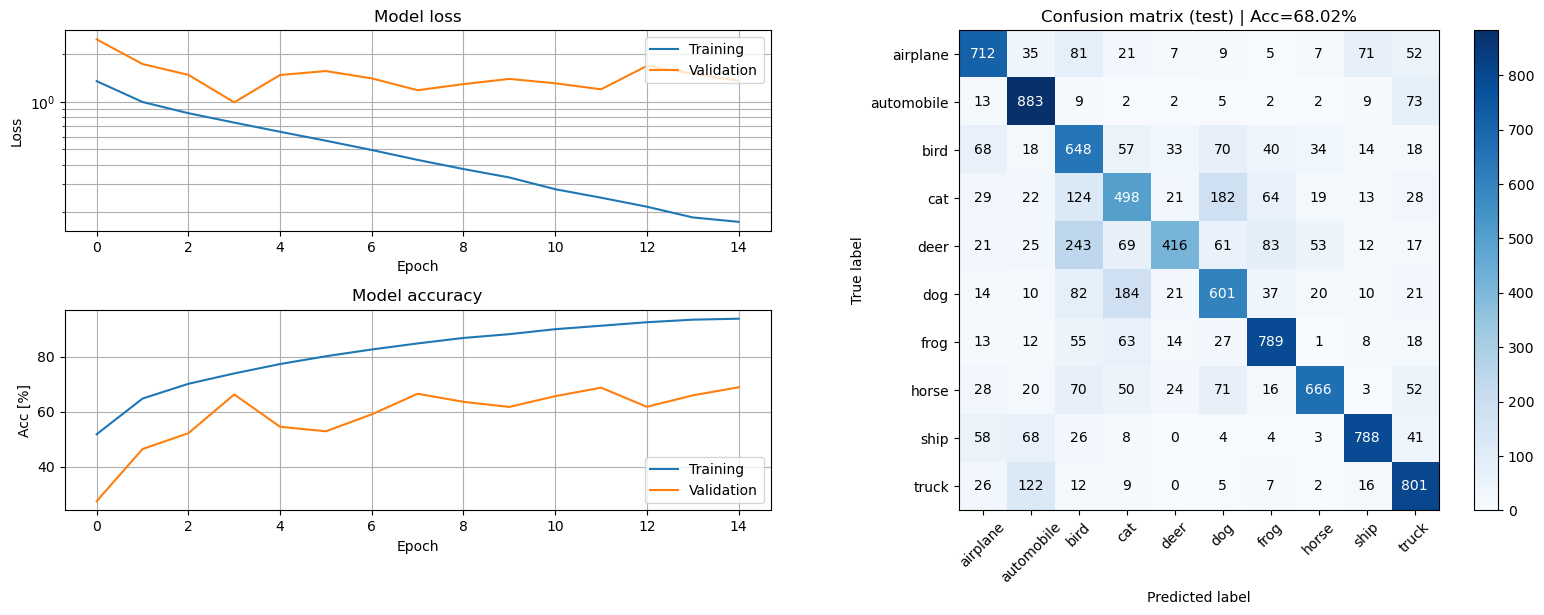

In [38]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def CreateCNNModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --- Block 1: Low-level features (Edges, Colors) ---
    # 32 filters/kernels, 3x3 kernel size (3x3x3 due to RGB)
    # Each kernel might capture a specific feature, such as a vertical edge, or a specific color pattern.
    # padding='same' keeps the output size 32x32 before pooling else it would be 30x30.
    x = Conv2D(32, (3, 3), padding='same')(x_in)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x) # Output shape is now 16x16
    
    # --- Block 2: Mid-level features (Shapes, Textures) ---
    # Increase filters to 64 to capture more complex patterns
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x) # Output shape is now 8x8

    # --- Block 3: High-level features ---
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    
    # --- Classifier ---
    # Flatten the 3D feature maps (8x8x64) into a 1D vector
    x = Flatten()(x)
    
    # Dense layer to interpret the features
    x = Dense(64)(x)
    x = Activation('relu')(x)
    
    # Final Output Layer (10 classes)
    x = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the CNN model
TrainModelAndPlotResults(CreateCNNModel)

Model: "model_6"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 input_7 (InputLayer)                        [(None, 32, 32, 3)]                     0              
                                                                                                    
 conv2d (Conv2D)                             (None, 32, 32, 32)                      896            
                                                                                                    
 activation_1 (Activation)                   (None, 32, 32, 32)                      0              
                                                                                                    
 max_pooling2d (MaxPooling2D)                (None, 16, 16, 32)                      0              
                                                                          

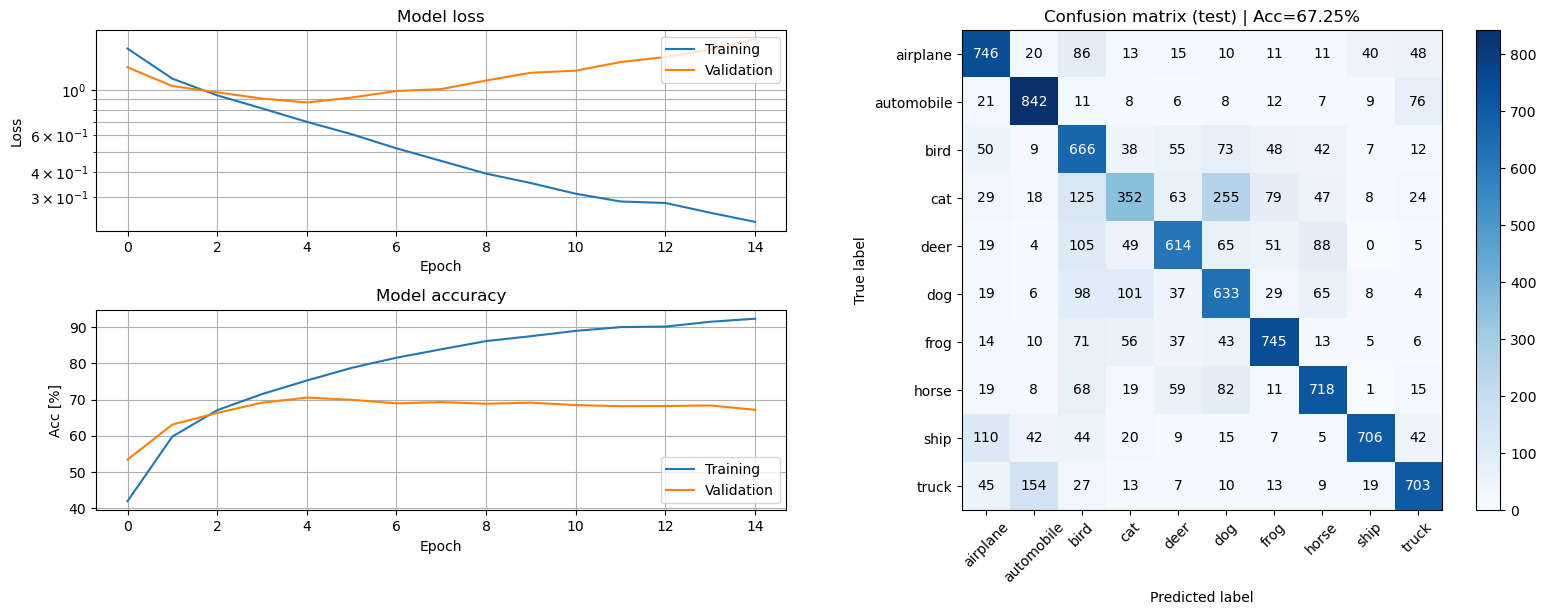

In [13]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def CreateCNNModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --- Block 1: Low-level features (Edges, Colors) ---
    # 32 filters/kernels, 3x3 kernel size (3x3x3 due to RGB)
    # Each kernel might capture a specific feature, such as a vertical edge, or a specific color pattern.
    # padding='same' keeps the output size 32x32 before pooling else it would be 30x30.
    x = Conv2D(32, (3, 3), padding='same')(x_in)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x) # Output shape is now 16x16
    
    # --- Block 2: Mid-level features (Shapes, Textures) ---
    # Increase filters to 64 to capture more complex patterns
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x) # Output shape is now 8x8

    # --- Block 3: High-level features ---
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    
    # --- Classifier ---
    # Flatten the 3D feature maps (8x8x64) into a 1D vector
    x = Flatten()(x)
    
    # Dense layer to interpret the features
    x = Dense(64)(x)
    x = Activation('relu')(x)
    
    # Final Output Layer (10 classes)
    x = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the CNN model
TrainModelAndPlotResults(CreateCNNModel)

#### **<span style="color:red">Question 4:</span>**
Train a model that achieves at least 62% test accuracy. Provide a (short) motivation of your model architecture and briefly discuss the results.

#### **<span style="color:green">Answer:</span>**

Architecture that increases depth while reducing image size. The first block (32 filters) captures low-level features like edges and colors. The subsequent blocks (64 filters) combine these into high-level features like shapes and object parts.

MaxPooling2D layers were used to downsample the image ($32 \to 16 \to 8$), reducing computation and making the model robust to small shifts in the image (translation invariance).

#### **<span style="color:red">Question 5:</span>**
Compare this model with the previous fully connected model. You should find that this one is much more efficient, i.e. achieves higher accuracy with fewer parameters. Explain in your own words how this is possible.

#### **<span style="color:green">Answer:</span>**

* The CNN is far more efficient because it uses **Parameter Sharing** instead of learning a separate weight for every single pixel (like a Fully Connected layer), a CNN learns a single small filter (kernel) (e.g., $3 \times 3$) and slides it across the entire image. This means the same "edge detector" is reused everywhere, drastically reducing the total number of parameters while still capturing the same information. 
* Additionally, Local Connectivity allows the network to focus on neighboring pixel relationships (shapes) rather than trying to find relationships between every distant pixel at once.

### **4. Regularization**

#### **4.1 Dropout**
You have probably seen that your CNN model overfits the training data. One way to prevent this is to add ```Dropout``` layers to the model, that randomly "drops" hidden nodes each training-iteration by setting their output to zero. Thus the model cannot rely on a small set of very good hidden features, but must instead learns to use different sets of hidden features each time. Dropout layers are usually added after activations in the fully connected potion of the model, while ```SpatialDropout2D``` layers are instead added after the pooling layers in the convolution part of the model. The reason we use ```SpatialDropout2D``` instead of Dropout in the convolution part is that dropping individual nodes in a feature map would destroy the spatial structure of the features. Instead, ```SpatialDropout2D``` drops entire feature maps at a time, preserving the spatial structure within each feature map.

*Side note. In the next assignment you will work with Ensemble models, a way to use the output from several individual models to achieve higher performance than each model can achieve on its own. One way to interpret Dropout is that each random selection of nodes is a separate model that is trained only on the current iteration. The final output is then the average of outputs from all the individual models. In other words, Dropout can be seen as a way to build ensembling directly into the network, without having to train several models explicitly.*

Extend your previous model with the ```Dropout``` and ```SpatialDropout2D``` layers and test the new performance. Note that good dropout rates are usually different for standard and spatial dropout.

Model: "model_7"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 input_8 (InputLayer)                        [(None, 32, 32, 3)]                     0              
                                                                                                    
 conv2d_3 (Conv2D)                           (None, 32, 32, 32)                      896            
                                                                                                    
 activation_5 (Activation)                   (None, 32, 32, 32)                      0              
                                                                                                    
 max_pooling2d_2 (MaxPooling2D)              (None, 16, 16, 32)                      0              
                                                                          

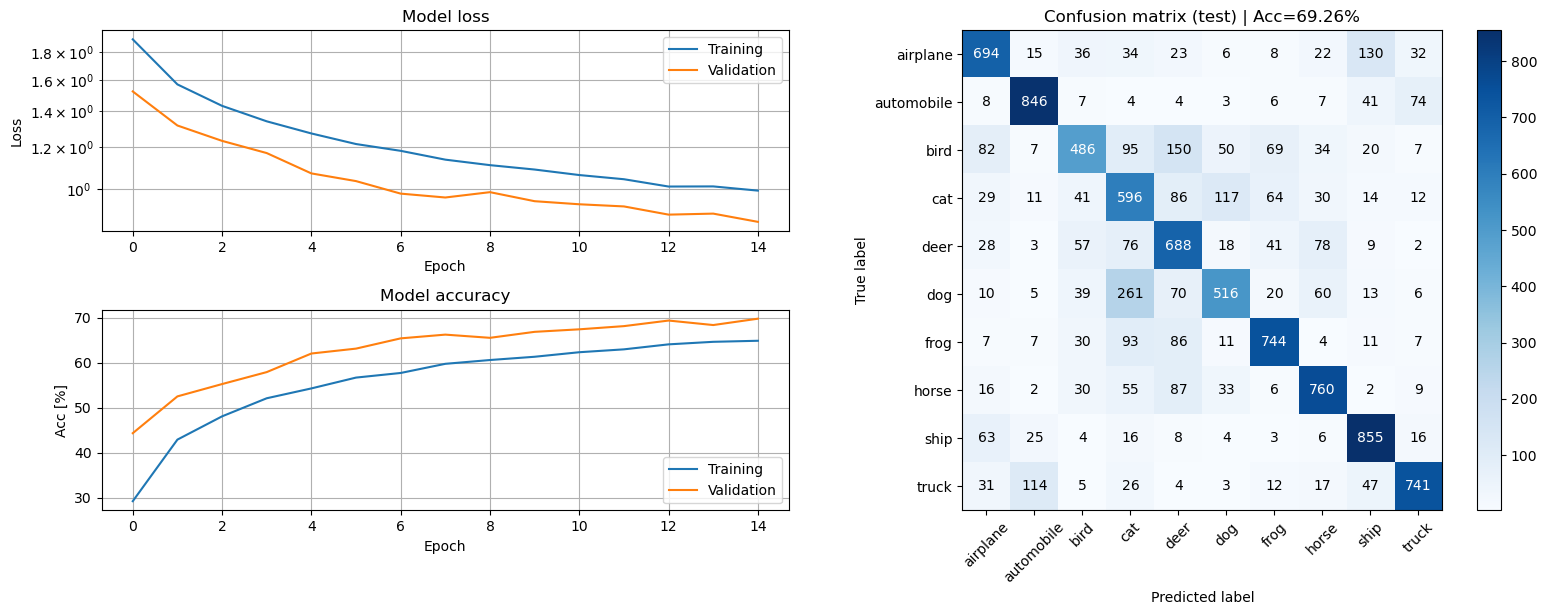

In [ ]:
from tensorflow.keras.layers import Dropout, SpatialDropout2D

def CreateDropoutModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --- Block 1 ---
    x = Conv2D(32, (3, 3), padding='same')(x_in)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    # SpatialDropout drops entire 2D feature maps, not just individual pixels.
    x = SpatialDropout2D(0.1)(x) # A rate of 10%
    
    # --- Block 2 ---
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = SpatialDropout2D(0.1)(x)

    # --- Block 3 ---
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    x = SpatialDropout2D(0.2)(x) 
    
    # --- Classifier Head ---
    x = Flatten()(x)
    
    x = Dense(64)(x)
    x = Activation('relu')(x)
    # Standard Dropout drops individual neurons. 
    x = Dropout(0.5)(x)
    
    # Final Output Layer
    x = Dense(10, activation='softmax')(x)

    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the Dropout model
TrainModelAndPlotResults(CreateDropoutModel)

#### **<span style="color:red">Question 6:</span>**
Compare this model and the previous in terms of the training accuracy, validation accuracy, and test accuracy. Explain the similarities and differences (remember that the only difference between the models should be the addition of Dropout layers).

Hint: what does the dropout layer do at test time?

#### **<span style="color:green">Answer:</span>**

Dropout stops the model from overfitting on the training data, we see that without dropout the model would overwfit on the training data and worsen on the validation data.

Without Dropout:  
        The model will achieve higher training accuracy because every neuron is always available during training, and   the network can  
        easily fit the training data set very well.  
    With Dropout:  
        The model will typically get a lower training accuracy compared to without because a fraction of the neurons   would not be available  
        during training which prevents the network too much on a particular set of neurons which leads to a decrease   chance of overfitting.  


#### **4.2 Batch normalization**
The final layer we will explore is ```BatchNormalization```. As the name suggests, this layer normalizes the data in each batch to have a specific mean and standard deviation, which is learned during training. The reason for this is quite complicated (and still debated among the experts), but suffice to say that it helps the optimization converge faster which means we get higher performance in fewer epochs. The normalization is done separatly for each feature, i.e. the statistics are calculated accross the batch dimension of the input data. The equations for batch-normalizing one feature are the following, where $N$ is the batch size, $x$ the input features, and $y$ the normalized output features:

$$ \mu = \frac{1}{N} \sum_{i=0}^{N}x_i,\;\;\;\; \sigma^2 = \frac{1}{N} \sum_{i=0}^{N}(x_i - \mu)^2 $$

$$ \hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} $$

$$ y_i = \gamma \hat{x}_i + \beta $$

At first glance this might look intimidating, but all it means is that we begin by scaling and shifting the data to have mean $\mu=0$ and standard deviation $\sigma=1$. After this we use the learnable parameters $\gamma$ and $\beta$ to decide the width and center of the final distribution. $\epsilon$ is a small constant value that prevents the denominator from being zero.

In addition to learning the parameters $\gamma$ and $\beta$ by gradient decent just like the weights, Batch Normalization also keeps track of the running average of minibatch statistics $\mu$ and $\sigma$. These averages are used to normalize the test data. We can tune the rate at which the running averages are updated with the *momentum* parameter of the BatchNormalization layer. A large momentum means that the statistics converge more slowly and therefore requires more updates before it represents the data. A low momentum, on the other hand, adapts to the data more quickly but might lead to unstable behaviour if the latest minibatches are not representative of the whole dataset. For this test we recommend a momentum of 0.75, but you probably want to change this when you design a larger network in Section 5.

The batch normalization layer should be added after the hidden layer linear transformation, but before the nonlinear activation. This means that we cannot specify the activation funciton in the ```Conv2D``` or ```Dense``` if we want to batch-normalize the output. We therefore need to use the ```Activation``` layer to add a separate activation to the network stack after batch normalization. For example, the convolution block will now look like **[conv - batchnorm - activation - pooling]**.

Extend your previous model with batch normalization, both in the convolution and fully connected part of the model.

Model: "model_8"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 input_9 (InputLayer)                        [(None, 32, 32, 3)]                     0              
                                                                                                    
 conv2d_6 (Conv2D)                           (None, 32, 32, 32)                      864            
                                                                                                    
 batch_normalization (BatchNormalization)    (None, 32, 32, 32)                      128            
                                                                                                    
 activation_9 (Activation)                   (None, 32, 32, 32)                      0              
                                                                          

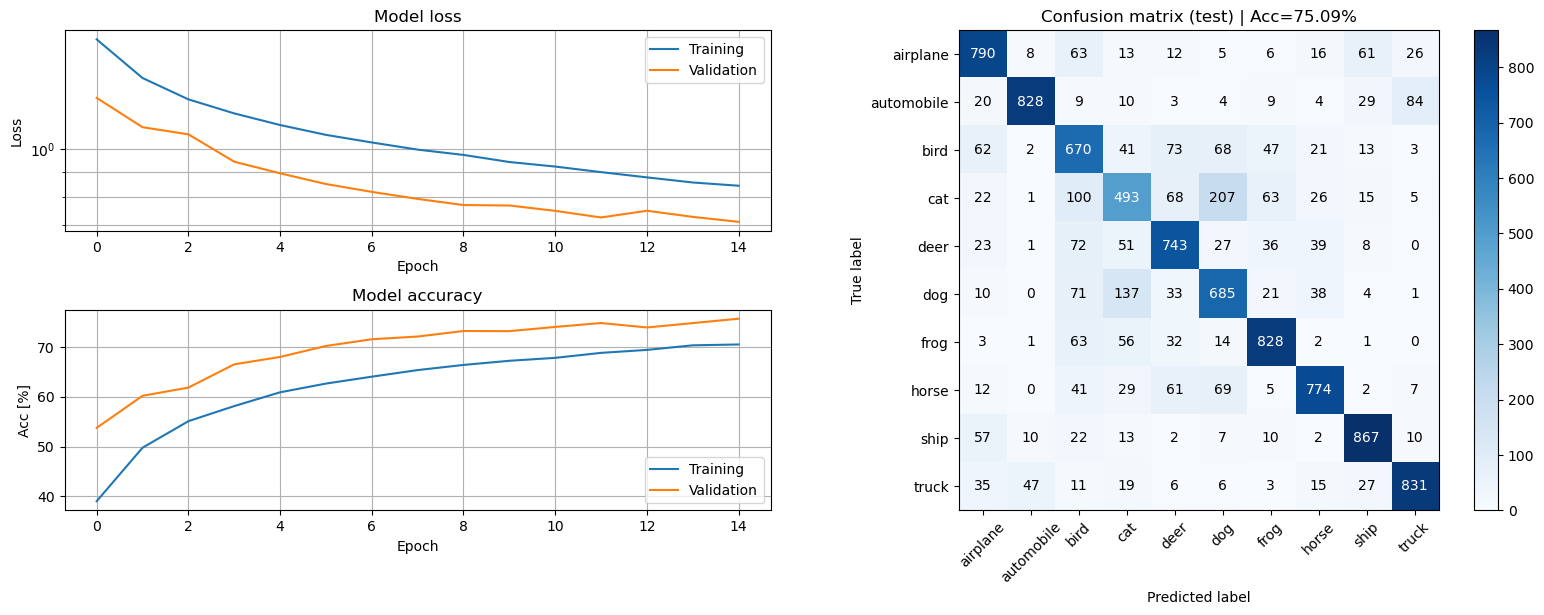

In [15]:
from tensorflow.keras.layers import Dropout, SpatialDropout2D, BatchNormalization, Activation, Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.models import Model

def CreateBatchNormModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --------------------------------------------
    # === Block 1 ===
    # Batch size 32 is used in the training loop (course instruction)

    # 1. Conv (Linear transformation) use_bias=False because BN handles the bias
    x = Conv2D(32, (3, 3), padding='same', use_bias=False)(x_in)
    x = BatchNormalization(momentum=0.75)(x) #momentum=0.75 per lab instructions
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = SpatialDropout2D(0.1)(x)
    
    # --------------------------------------------
    # === Block 2 ===

    x = Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization(momentum=0.75)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = SpatialDropout2D(0.1)(x)

    # --------------------------------------------
    # === Block 3 ===

    x = Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization(momentum=0.75)(x)
    x = Activation('relu')(x)
    x = SpatialDropout2D(0.2)(x) 
    
    # --------------------------------------------
    # === Classifier ===

    x = Flatten()(x)
    
    x = Dense(64, use_bias=False)(x)
    x = BatchNormalization(momentum=0.75)(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)
    
    # Final Output Layer (Softmax)
    x = Dense(10, activation='softmax')(x)

    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the BatchNorm model
TrainModelAndPlotResults(CreateBatchNormModel)

#### **<span style="color:red">Question 7:</span>**
When using BatchNorm one must take care to select a good minibatch size. Describe what problems might arise if:

1. The minibatch size is too small.
2. The minibatch size is too large.

You can reason about this given the description of BatchNorm above, or you can search for the information in other sources. Do not forget to provide links to the sources if you do!

#### **<span style="color:green">Answer:</span>**

Too Small: It might converge faster due to more updates but the calculated mean and variance might be unreliable because the sample size is so small. Sometimes the mean/variance will be more accurate but sometimes it will be very inaccurate --> noisy. 

Too Large: If the minibatch size is too large we need more computational power , the "noise" in the gradient estimate is reduced significantly, which can hurt generalization because that noise acts as a regularizer; furthermore, large batches require significantly more memory, potentially exceeding GPU limits without providing a proportional speedup in convergence.

**BatchNormalization** layers before activations. Previous attempts without this stabilization suffered from "gradient collapse" (stuck at 10% accuracy)

https://www.geeksforgeeks.org/data-science/what-are-the-rules-for-choosing-the-size-of-a-mini-batch/


Batch Normalization:
* Batch Norm forces the output of every layer to have a mean of 0 and a variance of 1.
* Layer 2 now sees a stable, predictable input, so it can focus on learning patterns immediately rather than adjusting to shifts.
* When using ReLU negative numbers becoms 0 (The neuron "dies") but BN re-centers the data and ensures roughly half of the inputs to reLU are positive --> Prevents the gradients from vanishing.

I choose ReLU because it improved the speed without lowering the performance noticebly max(0, x).

  
**Details:**
Without normalization, as the weights in the first layer change, the inputs to the second layer change wildly (shifting distribution). Layer 2 has to constantly "re-learn" what to expect from Layer 1. This is called Internal Covariate Shift.

### **5. Putting it all together**
We now want you to create your own model based on what you have learned. We want you to experiment and see what works and what doesn't, so don't go crazy with the number of epochs until you think you have something that works.

To pass this assignment, we want you to acheive **75%** accuracy on the test data in no more than **25 epochs**. This is possible using the layers and techniques we have explored in this notebook, but you are free to use any other methods that we didn't cover. (You are obviously not allowed to cheat, for example by training on the test data.)

In [20]:
from Custom import PlotModelEval

def TrainModelAndPlotResults2(get_model_func, epochs=20, batch_size=32):
    # Get model using function handle parameter
    model = get_model_func()

    # Build the model using Stochastic Gradient Descent with Nesterov momentum. We use accuracy as the metric.
    sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary(100)

    # Train the model and store the training history
    history = model.fit(X_train,y_train_c, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Evaluate on the test set and store the score
    score = model.evaluate(X_test, y_test_c, batch_size=128, verbose=0)

    # Print the result metrics
    print("")
    print('_' * 100)
    for i in range(len(score)):
        print("Test " + model.metrics_names[i] + " = %.3f" % score[i])
    print("")

    # Plot the training history and results
    PlotModelEval(model, history, X_test, y_test, cifar_labels)

Model: "model_11"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 input_12 (InputLayer)                       [(None, 32, 32, 3)]                     0              
                                                                                                    
 conv2d_15 (Conv2D)                          (None, 32, 32, 32)                      864            
                                                                                                    
 batch_normalization_12 (BatchNormalization)  (None, 32, 32, 32)                     128            
                                                                                                    
 activation_21 (Activation)                  (None, 32, 32, 32)                      0              
                                                                         

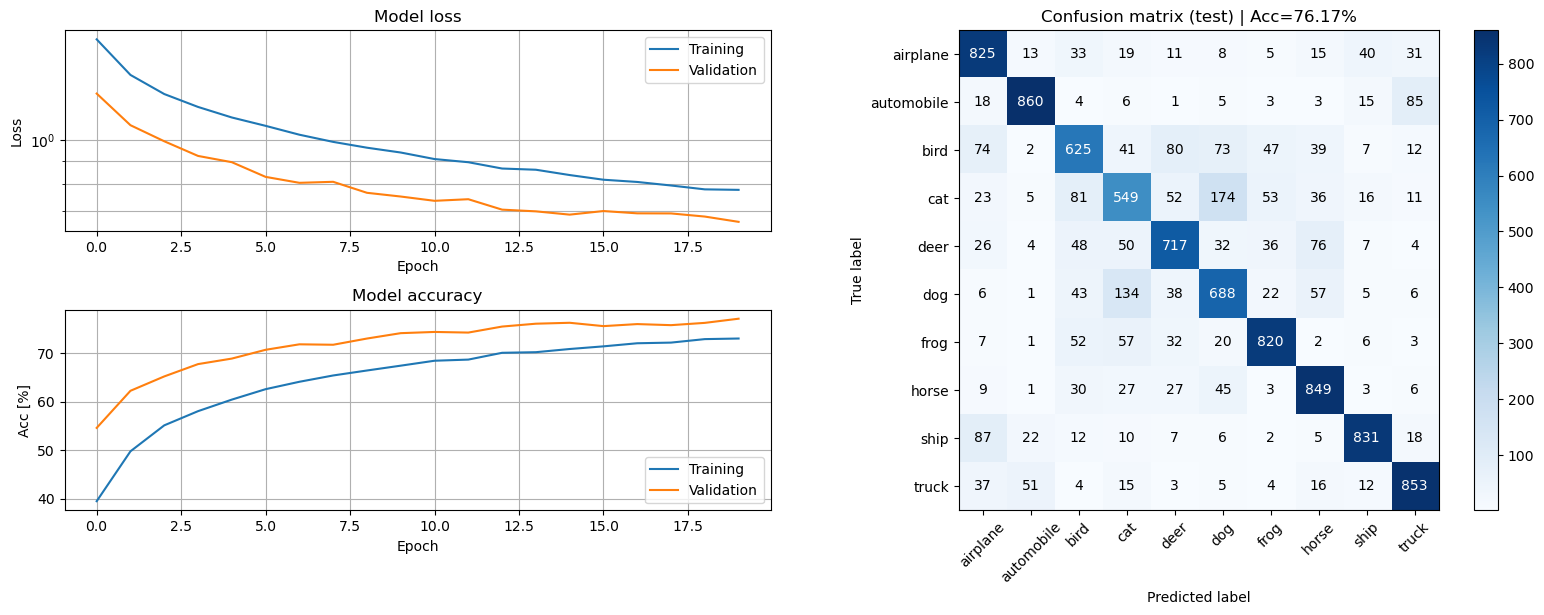

In [21]:
from tensorflow.keras.layers import Dropout, SpatialDropout2D, BatchNormalization, Activation, Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.models import Model

def CreateBatchNormModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --------------------------------------------
    # === Block 1 ===
    # Batch size 32 is used in the training loop (course instruction)

    # 1. Conv (Linear transformation) use_bias=False because BN handles the bias
    x = Conv2D(32, (3, 3), padding='same', use_bias=False)(x_in)
    x = BatchNormalization(momentum=0.75)(x) #momentum=0.75 per lab instructions
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = SpatialDropout2D(0.1)(x)
    
    # --------------------------------------------
    # === Block 2 ===

    x = Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization(momentum=0.75)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = SpatialDropout2D(0.1)(x)

    # --------------------------------------------
    # === Block 3 ===

    x = Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization(momentum=0.75)(x)
    x = Activation('relu')(x)
    x = SpatialDropout2D(0.2)(x) 
    
    # --------------------------------------------
    # === Classifier ===

    x = Flatten()(x)
    
    x = Dense(64, use_bias=False)(x)
    x = BatchNormalization(momentum=0.75)(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)
    
    # Final Output Layer (Softmax)
    x = Dense(10, activation='softmax')(x)

    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the BatchNorm model
TrainModelAndPlotResults2(CreateBatchNormModel)

#### **<span style="color:red">Question 8:</span>**
Design and train a model that achieves at least 75% test accuracy in at most 25 epochs. Explain your model architecture and motivate the design choices you have made.

#### **<span style="color:green">Answer:</span>**

I follow the architecture from the lecture

Conv(32) + BN + ReLU + MaxPooling(2,2) + SpatialDropout2D(01)
Conv(64) + BN + ReLU + MaxPooling(2,2) + SpatialDropout2D(01)
Conv(64) + BN + ReLU + SpatialDropout2D(01)

Flatten + Dense(64) + BN + ReLU + Dropout(0.5)

Dense(10) + SoftMAX

Layers and sizes:
* Fewer layers and smaller sizes didnt capture the complexity


---

### **Want some extra challenge?**
For those of you that want to get creative, here are some things to look into. But note that we don't have the answers here. Any of these might improve the performance, or might not, or it might only work in combination with each other. This is up to you to figure out. This is how deep learning research often happens, trying things in a smart way to see what works best.
* Tweak or change the optimizer or training parameters.
* Tweak the filter parameters, such as numbers and sizes of filters.
* Use other activation functions.
* Add L1/L2 regularization (see https://www.tensorflow.org/api_docs/python/tf/keras/regularizers)
* Include layers that we did not cover here (see https://www.tensorflow.org/api_docs/python/tf/keras/layers). For example, our best model uses the global pooling layers.
* Take inspiration from some well-known architectures, such as ResNet or VGG16. (But don't just copy-paste those architectures. For one, what's the fun in that? Also, they take a long time to train, you will not have time.)
* Use explicit model ensembing (training multiple models that vote on or average the outputs - this will also take a lot of time.)
* Use data augmentation to create a larger training set (see https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator).